In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## 1. Исследовательский анализ данных (Exploratory Data Analysis - EDA):

Для рекомендательной системы будем использовать дата-сет с оценками фильмов Netflix (Netflix Prize Data Set).

Т.к. файл с названиями фильмов в качестве разделителя использует запятую и в названии фильмов может быть запятая, то с загрузкой через pd.read_csv могут возникнуть проблемы.<br/>
Но в файле название фильма идет на последней правой позиции. Поэтому прочитаем файл построчно, и последнюю позицию выделим под называние фильма.

In [2]:
with open('movie_titles.txt', 'r', encoding = 'ISO-8859-1') as f:
    lines = f.readlines()

data = []
for line in lines:
    parts = line.strip().split(',')
    movie_id = parts[0]
    year = parts[1]
    name = ','.join(parts[2:])
    data.append([movie_id, year, name])

movies_df = pd.DataFrame(data, columns = ['Movie_Id', 'Year', 'Name'])

movies_df.head()

,Movie_Id,Year,Name
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW


Выведем уникальные значения года выхода фильма:

In [3]:
print(sorted(movies_df['Year'].unique()))

['1896', '1909', '1914', '1915', '1916', '1917', '1918', '1919', '1920', '1921', '1922', '1923', '1924', '1925', '1926', '1927', '1928', '1929', '1930', '1931', '1932', '1933', '1934', '1935', '1936', '1937', '1938', '1939', '1940', '1941', '1942', '1943', '1944', '1945', '1946', '1947', '1948', '1949', '1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', 'NULL']


Видно, что есть не значимые строковые значения 'NULL'. Посмотрим, сколько таких значений:

In [4]:
movies_df[movies_df['Year'] == 'NULL']

,Movie_Id,Year,Name
4387,4388,NULL,Ancient Civilizations: Rome and Pompeii
4793,4794,NULL,Ancient Civilizations: Land of the Pharaohs
7240,7241,NULL,Ancient Civilizations: Athens and Greece
10781,10782,NULL,Roti Kapada Aur Makaan
15917,15918,NULL,Hote Hote Pyaar Ho Gaya
16677,16678,NULL,Jimmy Hollywood
17666,17667,NULL,Eros Dance Dhamaka


Видно, что таких всего 7. Заменим их на NaN:

In [5]:
movies_df['Year'] = movies_df['Year'].replace('NULL', pd.NA)

Приведем ИД фильма к числовому типу:

In [6]:
movies_df = movies_df.astype({'Movie_Id': 'int32'}).set_index('Movie_Id')

Файл с рейтингами очень большой, поэтому для тестов сначала возьмем 1 млн. строк:

In [7]:
df = pd.read_csv(
    'total_ratings.csv',
    header = None,
    names = ['Movie_Id', 'Cust_Id', 'Rating', 'Date'],
    dtype = {
        'Movie_Id': 'int16',
        'Cust_Id': 'int32',
        'Rating': 'int8'
    },
    parse_dates = ['Date'],
    nrows = 10**6
)

df.head()

,Movie_Id,Cust_Id,Rating,Date
0,15802,2071969,4,2005-07-07
1,15802,1395430,3,2005-07-10
2,15802,716091,4,2005-07-18
3,15802,2329101,5,2005-07-20
4,15802,1017542,4,2005-08-01


Объединим все в один дата-сет:

In [8]:
df = df.merge(movies_df, on = 'Movie_Id', how = 'inner')
df.head()

,Movie_Id,Cust_Id,Rating,Date,Year,Name
0,15802,2071969,4,2005-07-07,1944,Laura
1,15802,1395430,3,2005-07-10,1944,Laura
2,15802,716091,4,2005-07-18,1944,Laura
3,15802,2329101,5,2005-07-20,1944,Laura
4,15802,1017542,4,2005-08-01,1944,Laura


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column    Non-Null Count    Dtype         
---  ------    --------------    -----         
 0   Movie_Id  1000000 non-null  int16         
 1   Cust_Id   1000000 non-null  int32         
 2   Rating    1000000 non-null  int8          
 3   Date      1000000 non-null  datetime64[us]
 4   Year      1000000 non-null  str           
 5   Name      1000000 non-null  str           
dtypes: datetime64[us](1), int16(1), int32(1), int8(1), str(2)
memory usage: 29.6 MB


In [10]:
df.describe()

,Movie_Id,Cust_Id,Rating,Date
count,1000000.000000,1.000000e+06,1000000.000000,1000000
mean,9533.366211,1.323599e+06,3.574357,2004-09-29 18:02:48.566399
min,8.000000,6.000000e+00,1.000000,1999-12-08 00:00:00
25%,5710.000000,6.615710e+05,3.000000,2004-04-15 00:00:00
50%,8376.000000,1.321634e+06,4.000000,2004-12-29 00:00:00
75%,14370.000000,1.985633e+06,4.000000,2005-07-03 00:00:00
max,17627.000000,2.649429e+06,5.000000,2005-12-31 00:00:00
std,5205.717825,7.645067e+05,1.112985,NaN


Из статистики видно, что в итоговом дата-сете отсутствуют пропуски.

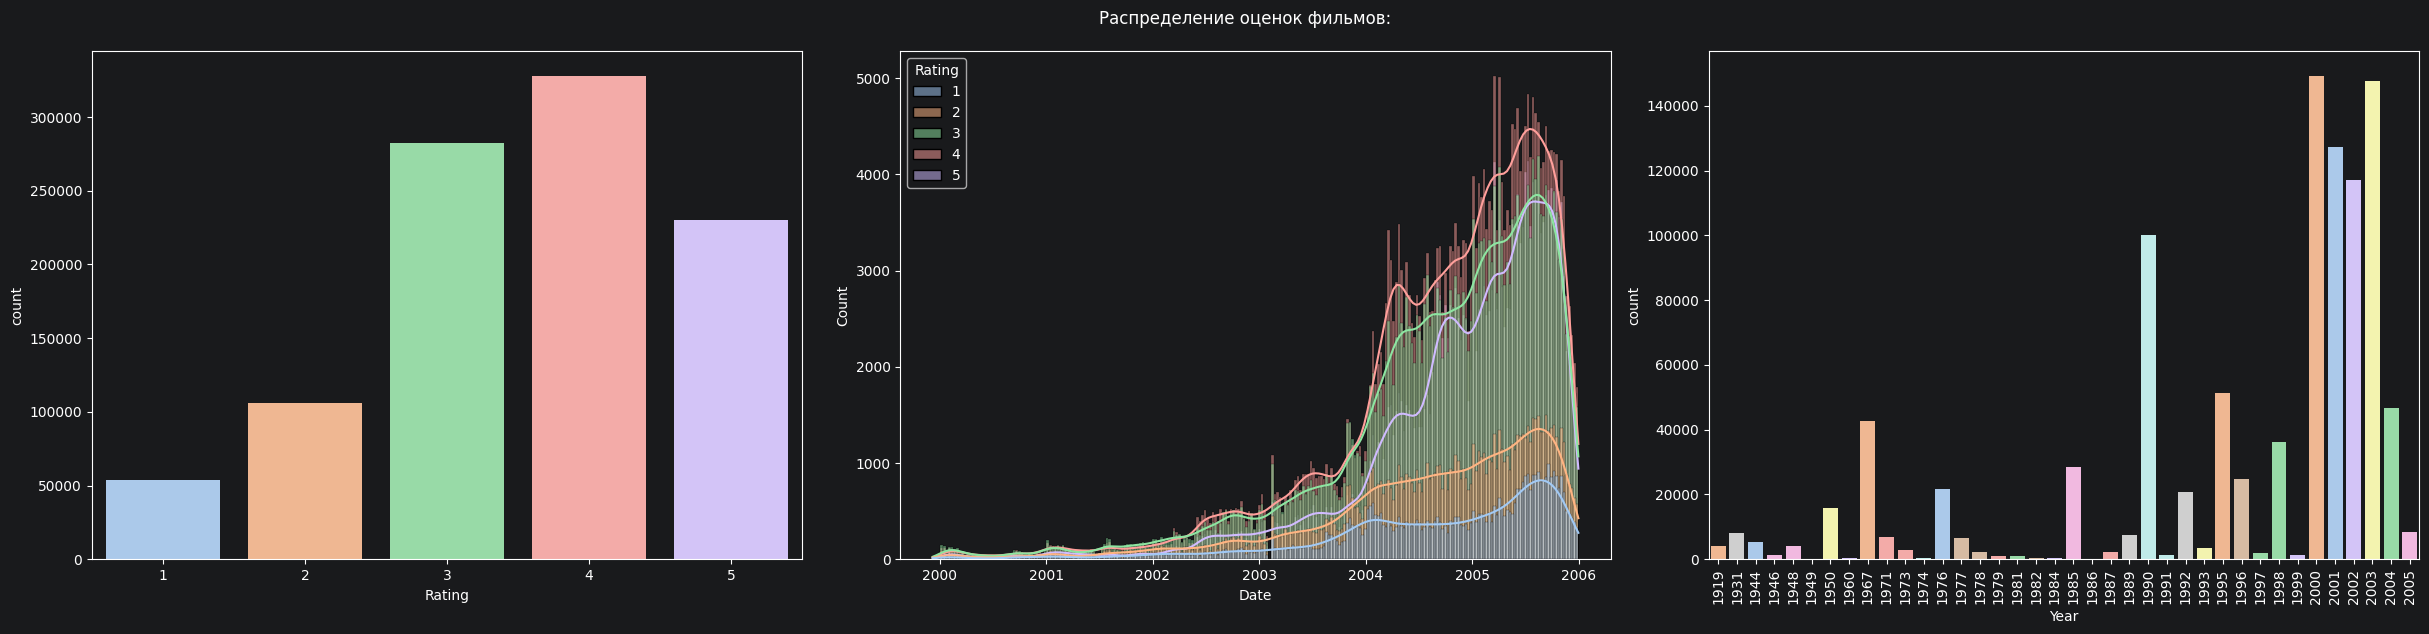

In [57]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (24, 6))
fig.suptitle('Распределение оценок фильмов:')
fig.tight_layout(w_pad = 4.0)

order = sorted(df['Year'].unique())
sns.countplot(data = df, x = 'Rating', hue = 'Rating', palette = 'pastel', legend = False, ax = axes[0])
sns.histplot(data = df, x = 'Date', hue = 'Rating', kde = True, palette = 'pastel', ax = axes[1])
sns.countplot(data = df, x = 'Year', hue = 'Year', legend = False, order = order, palette = 'pastel', ax = axes[2])
axes[2].set_xticks(order)
axes[2].set_xticklabels(labels = axes[2].get_xticklabels(), rotation = 90)

plt.show()

<ul>Из графиков ввидно:
<li>Самая популярная оценка равна 4;</li>
<li>С 2002 года постепенно растет кол-во оценок и достигает пика в 2005;</li>
<li>Самыми популярными являются фильмы 2000-2003 годов выпуска;</li>
</u>

Найдем самые полулярные фильмы с оценками 4 или 5 баллов:

In [41]:
df[df['Rating'] >= 4].groupby(['Movie_Id', 'Name'])['Rating'].count().sort_values(ascending = False).head(10)

Movie_Id  Name                                 
17627     Harry Potter and the Sorcerer's Stone    81857
5732      GoodFellas: Special Edition              75669
15563     Mona Lisa Smile                          47576
13102     Coyote Ugly                              38305
5561      Cool Hand Luke                           33811
8376      Unbreakable                              25326
3385      28 Days Later                            24673
8045      Open Range                               21854
7055      Get Shorty                               16240
8619      Pee-Wee's Big Adventure                  13140
Name: Rating, dtype: int64

Найдем самых активных пользователей:

In [46]:
df.groupby('Cust_Id')['Rating'].count().sort_values(ascending = False).head(10)

Cust_Id
305344     131
387418     129
1664010    125
2439493    122
2118461    116
1314869     81
1932594     76
1461435     75
1114324     74
1639792     71
Name: Rating, dtype: int64

## 2. Подготовка данных (Data Preprocessing):